<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
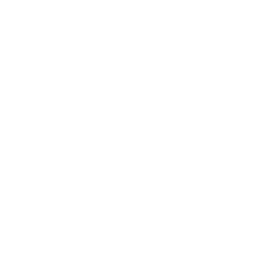
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Opetussuunnitelmien samankaltaisuusanalyysi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Korkeakoulutus / Akateemisten ohjelmien suunnittelu &nbsp;|&nbsp; Maaliskuu 2026</p>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Higher Education / Academic Program Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Tässä muistikirjassa mitataan opetussuunnitelmien päällekkäisyyttä
yliopiston kurssiluettelossa käyttäen **PROC DISTANCE** -proseduuria ja
menetelmää **METHOD=DJACCARD** — Jaccardin
*erilaisuuskerrointa*, joka on luonnollinen etäisyysmitta binääriselle
läsnäolo/poissaolo-datalle. Jokaisella kurssilla on 40 binääristä
merkintää, jotka osoittavat, mitkä akkreditoinnin oppimistulokset kurssi
kattaa, joten kahden kurssin välinen Jaccardin etäisyys on niiden
katettujen tulosten osuus, joita niillä **ei** ole yhteisenä
(0 = identtiset tulosjoukot, 1 = ei yhtään yhteistä tulosta).

Analyysi etenee kahdessa osassa. Ensin se profiloi 100 kurssin
luettelossa tulosten kattavuuden laajuutta laitoksittain (PROC MEANS, PROC FREQ,
kattavuuden laatikkokuvio) ja merkitsee oppimistulokset, joita **yksikään**
laitoksen kurssi ei kata (kattavuusaukot). Toiseksi se pureutuu
tarkennettuun 10 kurssin paneeliin, joka on koottu kahdesta määrällisesti
eniten päällekkäisestä laitoksesta — tilastotieteestä ja datatieteestä —
laskee täydellisen parittaisen Jaccardin etäisyysmatriisin ja asettaa
lähimmät kurssiparit paremmuusjärjestykseen
konsolidoinnin tarkastelun ehdokkaina. Tavoitteena on antaa opetussuunnitelma-
komitealle kaksi konkreettista tuotosta: paremmuusjärjestykseen asetettu luettelo
samankaltaisimmista kursseista sekä laitos–tulos-kohtainen aukkokartta.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binäärinen oppimistulosten kattavuus kurssia kohti (40 tulosmerkintää) | 100 |
| WORK.PANEL10 | Tilastotieteen + datatieteen konsolidointipaneeli | 10 |

Luettelo on synteettinen. Tulosmerkinnät on arvottu
laitoskohtaisilla todennäköisyyksillä siten, että tieteenalat painottavat
eri tulosklustereita (tietojenkäsittelytiede ja matematiikka painottavat
varhaisia tuloksia, laboratoriotieteet painottavat keskimmäistä kaistaa), mikä antaa
etäisyysanalyysille realistisen rakenteen. Tämä ympäristö toimii ilman lisenssiä,
joten työluettelo on rajattu 100 kurssiin.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic course learning-outcome matrix
   500 courses x 40 accreditation learning outcomes
   (unlicensed mode keeps the first 100)
   -------------------------------------------------------- */
TIEDOT work.course_outcomes;
    CALL streaminit(42);
    TAULUKKO outcomes[40] lo_1 - lo_40;
    TAULUKKO dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    TEE course_id = 1 ASTI 500;
        course_label = cat('CRS', KIRJOITA(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Course level affects outcome breadth */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Department-specific outcome clusters */
        TEE lo = 1 ASTI 40;
            base_prob = 0.15;
            /* Dept 1-2 (CS, Math): emphasize outcomes 1-15 */
            JOS dept_idx <= 2 AND lo <= 15 NIIN
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Stats, Eng): emphasize outcomes 10-25 */
            MUUTEN JOS dept_idx SISÄLLÄ (3, 4) AND 10 <= lo <= 25 NIIN
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Bio, Chem, Phys): emphasize 20-35 */
            MUUTEN JOS dept_idx SISÄLLÄ (5, 6, 7) AND 20 <= lo <= 35 NIIN
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Data Sci): broad coverage */
            MUUTEN JOS dept_idx = 8 NIIN
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        LOPPU;
        TULOSTE;
    LOPPU;
    POISTA dept_idx course_level base_prob lo;
SUORITA;

NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


In [2]:
/* --------------------------------------------------------
   Generate course catalog metadata
   -------------------------------------------------------- */
TIEDOT work.course_catalog;
    CALL streaminit(43);
    TAULUKKO dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    TAULUKKO format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    TEE course_id = 1 ASTI 500;
        course_label = cat('CRS-', KIRJOITA(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        TULOSTE;
    LOPPU;
    POISTA dept_idx format_idx;
    MUOTO last_offered date9.;
SUORITA;

NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                                  The MEANS Procedure

                                                Analysis Variable : LO_1

                                 N
        DEPARTMENT             Obs           Mean
        -----------------------------------------
        BIOLOGY                 10      0.2000000
        CHEMISTRY               19      0.2105263
        COMP_SCI                13      0.3846154
        DATA_SCI                14      0.1428571
        ENGINEERING             17      0.0000000
        MATH                     9      0.6666667
        PHYSICS                  7      0.2857143
        STATISTICS              11      0.0909091
        -----------------------------------------

                                                Analysis Variable : LO_2

                                 N
        DEPARTMENT             Obs           Mean
        -----------------------------------------
        BIOLOGY                 10      0.0000000
        CH

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


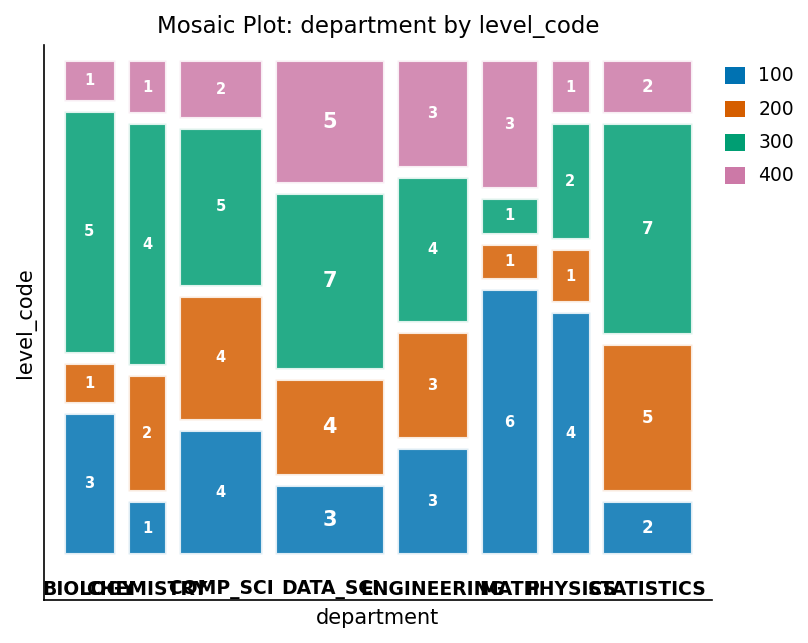

In [3]:
/* --------------------------------------------------------
   Baseline learning outcome coverage by department
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.course_outcomes mean;
    LUOKKA department;
    MUUTTUJA lo_1 - lo_40;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
SUORITA;

---

NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


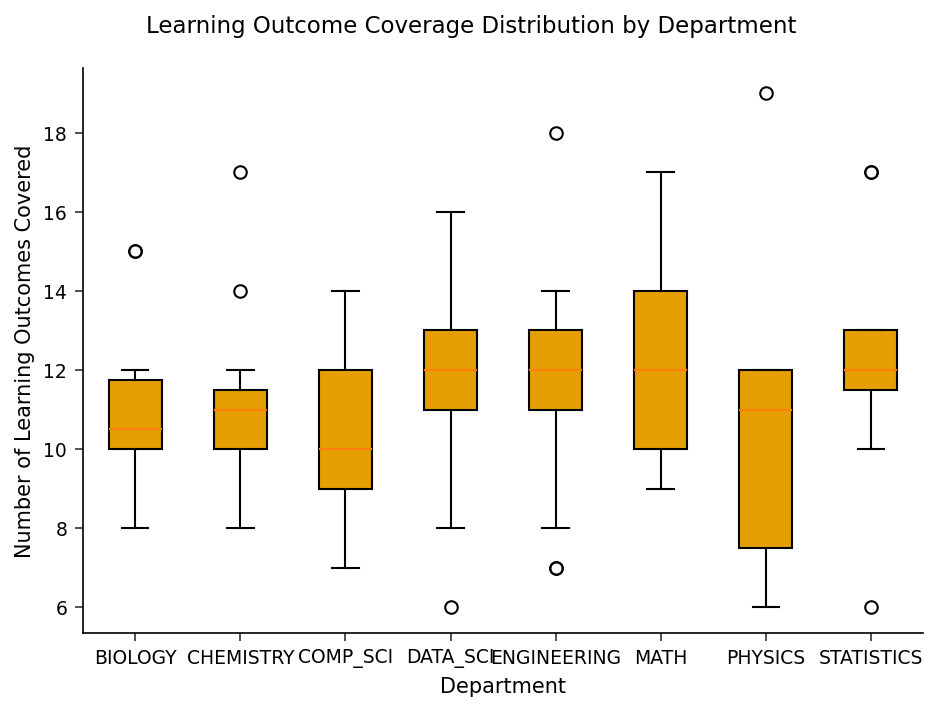

In [4]:
/* --------------------------------------------------------
   Outcome coverage density by department
   -------------------------------------------------------- */
TIEDOT work.outcome_counts;
    ASETA work.course_outcomes;
    TAULUKKO outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS NIMIKE='Number of Learning Outcomes Covered';
    XAXIS NIMIKE='Department';
    OTSIKKO 'Learning Outcome Coverage Distribution by Department';
SUORITA;

---

In [5]:
/* --------------------------------------------------------
   Consolidation panel: the first 10 Statistics / Data
   Science courses (the two most quantitatively overlapping
   departments). Re-label them P01-P10 with a sequential
   counter so the square OUT= distance matrix has clean,
   addressable columns, then compute the full pairwise
   Jaccard DISTANCE matrix with METHOD=DJACCARD
   (0 = identical outcome sets, 1 = no shared outcome).
   -------------------------------------------------------- */
TIEDOT work.panel10;
    ASETA work.course_outcomes(MISSÄ=(department SISÄLLÄ ('STATISTICS' 'DATA_SCI')));
    PIDÄ seq 0;
    seq + 1;
    JOS seq > 10 NIIN PYSÄYTÄ;
    panel_id = cat('P', KIRJOITA(seq, z2.));
    POISTA seq;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.panel10 noobs NIMIKE;
    MUUTTUJA panel_id course_label department level_code;
    NIMIKE panel_id = 'Panel ID' course_label = 'Course'
          department = 'Department' level_code = 'Level';
    OTSIKKO 'Consolidation Panel: Statistics and Data Science Courses';
SUORITA;

PROSEDUURI distance TIEDOT=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    MUUTTUJA nominal(lo_1 - lo_40);
    id panel_id;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.panel_dist noobs;
    OTSIKKO 'Pairwise Jaccard Distance Matrix (10 Courses)';
SUORITA;

                                Consolidation Panel: Statistics and Data Science Courses                                

Panel ID   Course  Department  Level
P01       CRS0003  DATA_SCI      300
P02       CRS0006  STATISTICS    300
P03       CRS0014  DATA_SCI      300
P04       CRS0015  STATISTICS    300
P05       CRS0017  STATISTICS    200
P06       CRS0019  DATA_SCI      100
P07       CRS0022  STATISTICS    400
P08       CRS0033  DATA_SCI      200
P09       CRS0038  STATISTICS    100
P10       CRS0040  STATISTICS    100

                                Consolidation Panel: Statistics and Data Science Courses                                

                                     Pairwise Jaccard Distance Matrix (10 Courses)                                      

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.8571428571  0.8260869565  0.8095238095  0.7391304348  0

NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reshape the square distance matrix into a ranked list of
   course pairs. The OUT= distance columns are addressed by
   an explicit name list (P01 P02 ... P10); only the strict
   upper triangle (col > row) is kept so each unordered pair
   appears once and the zero diagonal is skipped. The five
   closest pairs are the consolidation-review candidates.
   -------------------------------------------------------- */
TIEDOT work.similar_courses;
    ASETA work.panel_dist;
    TAULUKKO d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    PITUUS course_a course_b $8;
    course_a = _name_;
    row + 1;
    TEE col = 1 ASTI 10;
        JOS col > row NIIN TEE;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ course_a course_b jaccard_dist;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    MUUTTUJA jaccard_dist;
    OTSIKKO 'Distribution of Pairwise Jaccard Distances (45 Course Pairs)';
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=work.similar_courses; MUKAAN jaccard_dist; SUORITA;

TIEDOT work.top_pairs;
    ASETA work.similar_courses;
    pair_rank = _n_;
    JOS pair_rank <= 5;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.top_pairs noobs NIMIKE;
    MUUTTUJA pair_rank course_a course_b jaccard_dist;
    NIMIKE pair_rank = 'Rank' course_a = 'Course A'
          course_b = 'Course B' jaccard_dist = 'Jaccard Distance';
    OTSIKKO 'Five Closest Course Pairs (Consolidation Candidates)';
SUORITA;

                              Distribution of Pairwise Jaccard Distances (45 Course Pairs)                              

                                                  The MEANS Procedure

 Variable            N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------
 JACCARD_DIST       45       0.588            0.756       0.826       0.818       0.962
 --------------------------------------------------------------------------------------

                                  Five Closest Course Pairs (Consolidation Candidates)                                  

Rank  Course A  Course B  Jaccard Distance
   1  P02       P10                  0.588
   2  P03       P04                    0.6
   3  P03       P05                  0.667
   4  P02       P04                  0.684
   5  P02       P07                  0.684



NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                       Uncovered Learning Outcomes per Department                                       

                                                   The FREQ Procedure

DEPARTMENT     Frequency    Percent
------------------------------------
BIOLOGY                8     26.67
CHEMISTRY              2      6.67
COMP_SCI               3     10.00
ENGINEERING            2      6.67
MATH                   4     13.33
PHYSICS                8     26.67
STATISTICS             3     10.00
                                          Sample Outcome Gaps (first 12 of 30)                                          

Department  Uncovered Outcome
BIOLOGY     LO02
BIOLOGY     LO10
BIOLOGY     LO15
BIOLOGY     LO16
BIOLOGY     LO17
BIOLOGY     LO18
BIOLOGY     LO36
BIOLOGY     LO37
CHEMISTRY   LO02
CHEMISTRY   LO12
COMP_SCI    LO29
COMP_SCI    LO35

... 18 more observations (showing 12 of 30)



NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


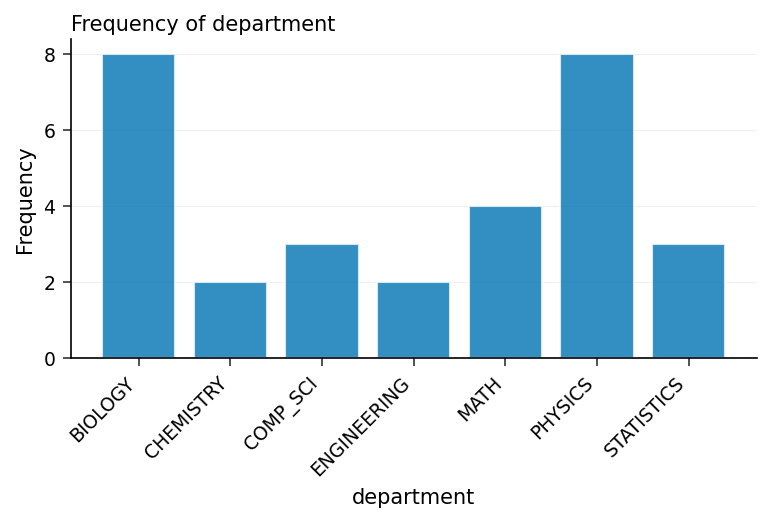

In [7]:
/* --------------------------------------------------------
   Outcome gaps: learning outcomes that NO course in a
   department covers. PROC MEANS sums each binary outcome
   flag within department; a sum of zero means the
   outcome is absent from that department's catalog.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.course_outcomes sum NOPRINT;
    LUOKKA department;
    MUUTTUJA lo_1 - lo_40;
    TULOSTE out=work.dept_coverage(MISSÄ=(_type_=1))
        sum=lo_1 - lo_40;
SUORITA;

TIEDOT work.outcome_gaps;
    ASETA work.dept_coverage;
    TAULUKKO outcomes[40] lo_1 - lo_40;
    TEE lo = 1 ASTI 40;
        outcome_id = cat('LO', KIRJOITA(lo, z2.));
        courses_covering = outcomes[lo];
        JOS courses_covering = 0 NIIN TEE;
            gap_flag = 1;
            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ department outcome_id courses_covering gap_flag;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.outcome_gaps;
    TABLES department / nocum;
    OTSIKKO 'Uncovered Learning Outcomes per Department';
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.outcome_gaps(obs=12) noobs NIMIKE;
    MUUTTUJA department outcome_id;
    NIMIKE department = 'Department' outcome_id = 'Uncovered Outcome';
    OTSIKKO 'Sample Outcome Gaps (first 12 of 30)';
SUORITA;

---

### Tulkinta

**Konsolidointipaneeli.** 10 kurssin tilastotieteen / datatieteen
paneelin 45 järjestämättömän parin joukossa Jaccardin etäisyys vaihtelee
välillä 0.588–0.962 mediaanin ollessa 0.826 (keskiarvo 0.818). Lähin
pari on P02 ja P10 etäisyydellä 0.588, joita seuraavat
P03–P04 etäisyydellä 0.600 ja P03–P05 etäisyydellä 0.667. Jopa
samankaltaisimmat kurssit eroavat silti noin 59 %:ssa katetuista
tuloksistaan, joten tämä luettelo ei sisällä **yhtään lähes päällekkäistä kurssia** — ei
ole yhtään paria, jonka komitea voisi yhdistää suoraan. Paremmuusjärjestykseen asetettu luettelo sen sijaan
osoittaa ne muutamat parit, joita kannattaa verrata manuaalisesti opetussuunnitelmatasolla ennen
seuraavaa luettelokierrosta; suurimman etäisyyden parit (lähellä 0.962) vahvistavat,
että tilastotieteen ja datatieteen kurssit kattavat aidosti erilaiset tulosjoukot
jaetusta laitosnaapuruudesta huolimatta.

**Kattavuusaukot.** Kolmekymmentä laitos–tulos-kohtaista aukkoa nousee esiin
luettelosta. Laboratoriopainotteiset tieteenalat kantavat niistä eniten: **biologia** ja
**fysiikka** jättävät kumpikin 8 kattamatta 40:stä akkreditointituloksesta,
joita seuraa **matematiikka** (4). Määrälliset laitokset ovat
parhaiten katettuja — **kemia** ja **tekniikka** jättävät kattamatta vain 2 tulosta
kumpikin. Nämä aukot ovat luonnollisia kohteita uusien kurssien kehittämiselle tai
ristiinlistaukselle: koko laitokselta puuttuva tulos on kattavuus-
riski akkreditoinnin uusinnassa, kun taas konsolidointiluettelo käsittelee
päinvastaista päällekkäisen työn ongelmaa. Yhdessä nämä kaksi tuotosta antavat
komitealle mahdollisuuden tiukentaa luetteloa molemmista päistä — karsimalla päällekkäisyyttä
ja täyttämällä aukkoja — käyttäen yhtä joukkopohjaista etäisyysmittaa.

---

In [8]:
/* --------------------------------------------------------
   Export the ranked consolidation candidates and the
   department outcome-gap map for the curriculum committee.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
SUORITA;

NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>